In [39]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.plot import show
import os

In [41]:
#paths
DEM= r"corridor_DEM.tiff"
HIGHWAYS= r"NH.shp"
CROSSINGS= r"drainage_crossing.shp"
OUTPUT_MAPS=r"D:\portfolio\outputs\maps"

os.makedirs(OUTPUT_MAPS, exist_ok=True)

## Loading and inspecting DEM

In [44]:
with rasterio.open(DEM) as src:
    dem_array = src.read(1).astype(float)
    transform = src.transform
    crs       = src.crs
    nodata    = src.nodata
    pixel_size = transform[0]

#replacing nodata with nan
if nodata is not None:
    dem_array[dem_array == nodata] = np.nan

print(f"DEM shape        : {dem_array.shape}")
print(f"Pixel size       : {pixel_size:.1f} metres")
print(f"CRS              : {crs}")
print(f"Min elevation    : {np.nanmin(dem_array):.1f} m")
print(f"Max elevation    : {np.nanmax(dem_array):.1f} m")
print(f"Mean elevation   : {np.nanmean(dem_array):.1f} m")
print(f"Elevation range  : {np.nanmax(dem_array) - np.nanmin(dem_array):.1f} m")

DEM shape        : (336, 1014)
Pixel size       : 28.2 metres
CRS              : EPSG:32645
Min elevation    : 1167.0 m
Max elevation    : 1687.0 m
Mean elevation   : 1359.9 m
Elevation range  : 520.0 m


## Plotting elevation map

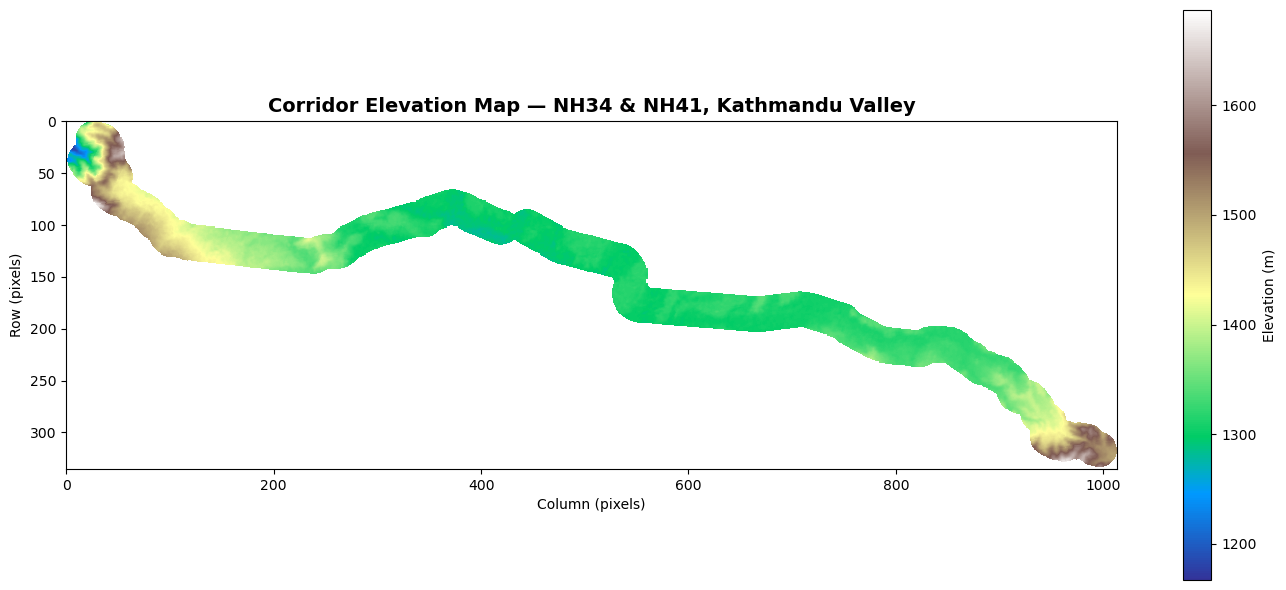

evelation map saved


In [47]:
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(dem_array, cmap='terrain',
               vmin=np.nanmin(dem_array),
               vmax=np.nanmax(dem_array))
plt.colorbar(im, ax=ax, label='Elevation (m)')
ax.set_title('Corridor Elevation Map — NH34 & NH41, Kathmandu Valley',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Column (pixels)')
ax.set_ylabel('Row (pixels)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_MAPS, 'elevation_map.png'), dpi=150)
plt.show()
print("evelation map saved")

## SLOPE CALCULATION

In [50]:
dy, dx = np.gradient(dem_array, pixel_size)
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

print(f"Slope min : {np.nanmin(slope_deg):.1f}°")
print(f"Slope max : {np.nanmax(slope_deg):.1f}°")
print(f"Slope mean: {np.nanmean(slope_deg):.1f}°")

Slope min : 0.0°
Slope max : 55.7°
Slope mean: 7.4°


## SLOPE CLASSIFICATION AND SUMMARY TABLE

In [53]:
slope_class = np.zeros_like(slope_deg)
slope_class[slope_deg <= 15]                       = 1  # flat
slope_class[(slope_deg > 15) & (slope_deg <= 30)]  = 2  # moderate
slope_class[slope_deg > 30]                        = 3  # steep

flat     = np.sum(slope_class == 1)
moderate = np.sum(slope_class == 2)
steep    = np.sum(slope_class == 3)
total    = flat + moderate + steep

print("─" * 40)
print(f"{'Slope Class':<20} {'Area %':>8}")
print("─" * 40)
print(f"{'Flat (0–15°)':<20} {flat/total*100:>7.1f}%")
print(f"{'Moderate (15–30°)':<20} {moderate/total*100:>7.1f}%")
print(f"{'Steep (>30°)':<20} {steep/total*100:>7.1f}%")
print("─" * 40)

────────────────────────────────────────
Slope Class            Area %
────────────────────────────────────────
Flat (0–15°)            87.9%
Moderate (15–30°)        9.4%
Steep (>30°)             2.7%
────────────────────────────────────────


## SLOPE CLASSIFICATION MAP

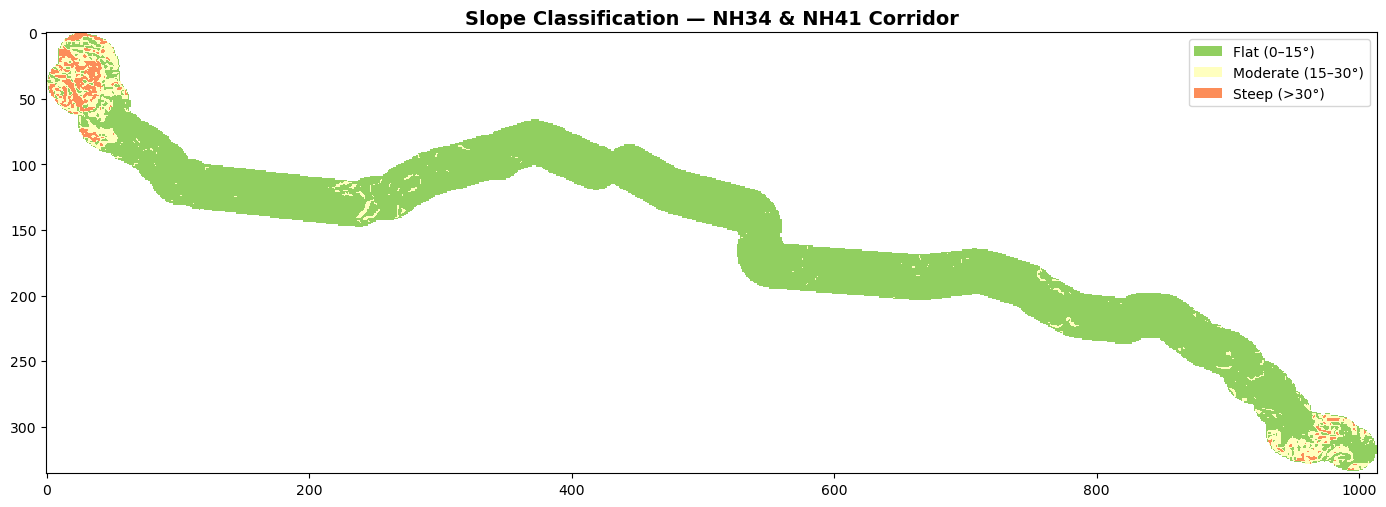

In [56]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

# masking nodata (0 values outside corridor)
slope_masked = np.where(dem_array == 0, np.nan, slope_class)
slope_masked = np.where(np.isnan(dem_array), np.nan, slope_class)

cmap = ListedColormap(['#91CF60', '#FFFFBF', '#FC8D59'])

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(slope_masked, cmap=cmap, vmin=1, vmax=3)

legend_elements = [
    Patch(facecolor='#91CF60', label='Flat (0–15°)'),
    Patch(facecolor='#FFFFBF', label='Moderate (15–30°)'),
    Patch(facecolor='#FC8D59', label='Steep (>30°)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
ax.set_title('Slope Classification — NH34 & NH41 Corridor',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_MAPS, 'slope_classification.png'), dpi=150)
plt.show()

## ELEVATION PROFILE

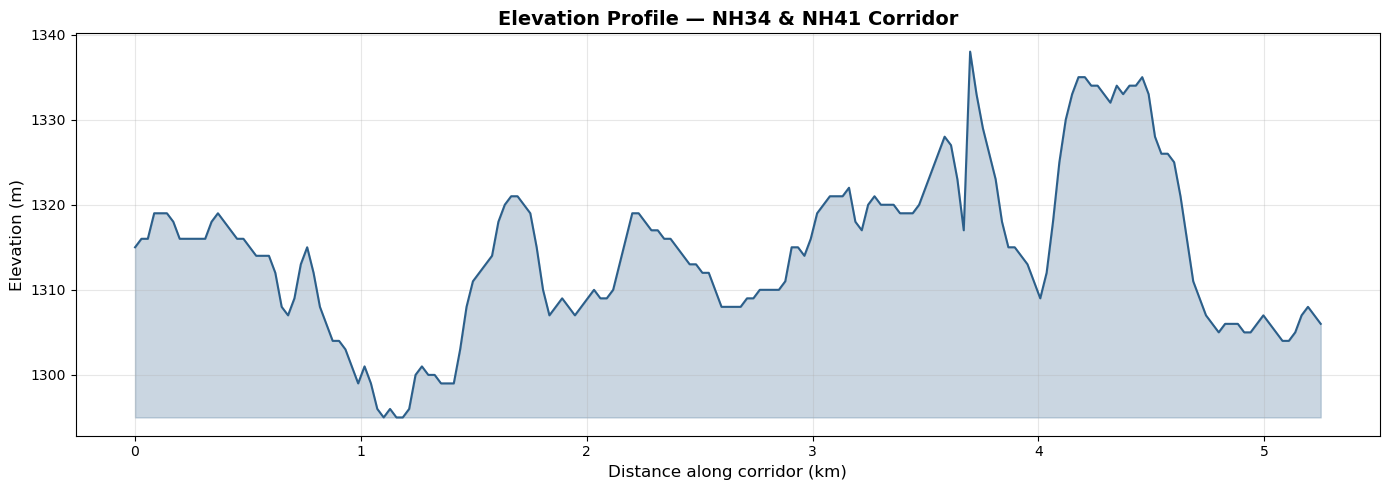

 elevation profile saved


In [59]:
mid_row  = dem_array.shape[0] // 2
profile  = dem_array[mid_row, :]
profile  = profile[~np.isnan(profile)]
distance = np.arange(len(profile)) * pixel_size / 1000  # km

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(distance, profile, color='#2C5F8A', linewidth=1.5)
ax.fill_between(distance, profile, profile.min(),
                alpha=0.25, color='#2C5F8A')
ax.set_xlabel('Distance along corridor (km)', fontsize=12)
ax.set_ylabel('Elevation (m)', fontsize=12)
ax.set_title('Elevation Profile — NH34 & NH41 Corridor',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_MAPS, 'elevation_profile.png'), dpi=150)
plt.show()
print(" elevation profile saved")

## Summary of drainage crossings

In [62]:
crossings = gpd.read_file(CROSSINGS)

print(f"Total drainage crossings : {len(crossings)}")
print(f"Columns available        : {list(crossings.columns)}")
print()

if 'ref' in crossings.columns:
    summary = crossings.groupby('ref').size().reset_index(name='Crossings')
    summary.columns = ['Highway', 'Crossing Count']
    print("─" * 35)
    print(f"{'Highway':<20} {'Crossings':>10}")
    print("─" * 35)
    for _, row in summary.iterrows():
        print(f"{str(row['Highway']):<20} {row['Crossing Count']:>10}")
    print("─" * 35)

Total drainage crossings : 16
Columns available        : ['SEGMENT_ID', 'NODE_A', 'NODE_B', 'BASIN', 'ORDER', 'ORDER_CELL', 'LENGTH', 'fid', 'osm_id', 'code', 'fclass', 'name', 'ref', 'oneway', 'maxspeed', 'layer', 'bridge', 'tunnel', 'CROSS_ID', 'geometry']

───────────────────────────────────
Highway               Crossings
───────────────────────────────────
NH34                         11
NH41                          5
───────────────────────────────────


## comparison chart (NH34 vs NH41)

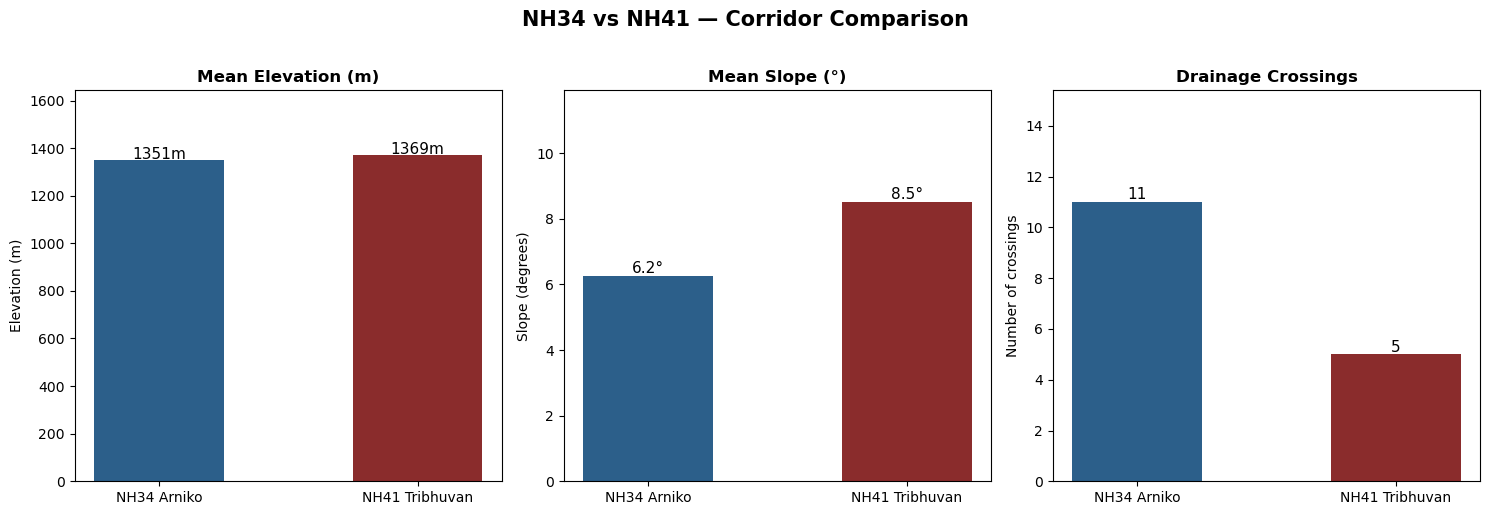

HIGHWAY COMPARISON SAVED


In [69]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

# loading crossings
crossings = gpd.read_file(CROSSINGS)

# counting crossings per highway
nh34_crossings = len(crossings[crossings['ref'].str.contains('34', na=False)])
nh41_crossings = len(crossings[crossings['ref'].str.contains('41', na=False)])

# elevation stats per highway using the DEM array
# NH34 runs roughly left half, NH41 right half of corridor
mid = dem_array.shape[1] // 2
nh34_elev = dem_array[:, mid:]
nh41_elev = dem_array[:, :mid]

nh34_elev = nh34_elev[~np.isnan(nh34_elev)]
nh41_elev = nh41_elev[~np.isnan(nh41_elev)]

# slope statistics
nh34_slope = slope_deg[:, mid:]
nh41_slope = slope_deg[:, :mid]
nh34_slope = nh34_slope[~np.isnan(nh34_slope)]
nh41_slope = nh41_slope[~np.isnan(nh41_slope)]

# plot 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('NH34 vs NH41 — Corridor Comparison',
             fontsize=15, fontweight='bold', y=1.02)

highways  = ['NH34 Arniko', 'NH41 Tribhuvan']
colors    = ['#2C5F8A', '#8A2C2C']

# chart 1: mean elevation
mean_elevs = [np.mean(nh34_elev), np.mean(nh41_elev)]
axes[0].bar(highways, mean_elevs, color=colors, width=0.5)
axes[0].set_title('Mean Elevation (m)', fontweight='bold')
axes[0].set_ylabel('Elevation (m)')
for i, v in enumerate(mean_elevs):
    axes[0].text(i, v + 5, f'{v:.0f}m', ha='center', fontsize=11)
axes[0].set_ylim(0, max(mean_elevs) * 1.2)

# chart 2: mean slope
mean_slopes = [np.mean(nh34_slope), np.mean(nh41_slope)]
axes[1].bar(highways, mean_slopes, color=colors, width=0.5)
axes[1].set_title('Mean Slope (°)', fontweight='bold')
axes[1].set_ylabel('Slope (degrees)')
for i, v in enumerate(mean_slopes):
    axes[1].text(i, v + 0.1, f'{v:.1f}°', ha='center', fontsize=11)
axes[1].set_ylim(0, max(mean_slopes) * 1.4)

# chart 3: drainage crossings
crossing_counts = [nh34_crossings, nh41_crossings]
axes[2].bar(highways, crossing_counts, color=colors, width=0.5)
axes[2].set_title('Drainage Crossings', fontweight='bold')
axes[2].set_ylabel('Number of crossings')
for i, v in enumerate(crossing_counts):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontsize=11)
axes[2].set_ylim(0, max(crossing_counts) * 1.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_MAPS, 'nh34_vs_nh41_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("HIGHWAY COMPARISON SAVED")

## FULL SUMMARY REPORT

In [72]:
print("=" * 55)
print("  CORRIDOR TERRAIN ANALYSIS — SUMMARY REPORT")
print("  NH34 Arniko & NH41 Tribhuvan, Kathmandu Valley")
print("=" * 55)

print(f"""
STUDY AREA
  Districts     : Kathmandu, Lalitpur, Bhaktapur
  Corridor width: 500m either side of highway
  Projection    : UTM Zone 45N (EPSG:32645)
  DEM source    : SRTM 30m (Copernicus)

ELEVATION STATISTICS
  Min elevation : {np.nanmin(dem_array):.1f} m
  Max elevation : {np.nanmax(dem_array):.1f} m
  Mean elevation: {np.nanmean(dem_array):.1f} m
  Total range   : {np.nanmax(dem_array) - np.nanmin(dem_array):.1f} m

SLOPE CLASSIFICATION
  Flat     (0–15°) : {flat/total*100:.1f}%
  Moderate (15–30°): {moderate/total*100:.1f}%
  Steep    (>30°)  : {steep/total*100:.1f}%

DRAINAGE CROSSINGS
  NH34 Arniko Highway  : {nh34_crossings} crossings
  NH41 Tribhuvan Highway: {nh41_crossings} crossings
  Total                : {len(crossings)} crossings

OUTPUTS SAVED
  maps/elevation_map.png
  maps/slope_classification.png
  maps/elevation_profile.png
  maps/nh34_vs_nh41_comparison.png
""")
print("=" * 55)

  CORRIDOR TERRAIN ANALYSIS — SUMMARY REPORT
  NH34 Arniko & NH41 Tribhuvan, Kathmandu Valley

STUDY AREA
  Districts     : Kathmandu, Lalitpur, Bhaktapur
  Corridor width: 500m either side of highway
  Projection    : UTM Zone 45N (EPSG:32645)
  DEM source    : SRTM 30m (Copernicus)

ELEVATION STATISTICS
  Min elevation : 1167.0 m
  Max elevation : 1687.0 m
  Mean elevation: 1359.9 m
  Total range   : 520.0 m

SLOPE CLASSIFICATION
  Flat     (0–15°) : 87.9%
  Moderate (15–30°): 9.4%
  Steep    (>30°)  : 2.7%

DRAINAGE CROSSINGS
  NH34 Arniko Highway  : 11 crossings
  NH41 Tribhuvan Highway: 5 crossings
  Total                : 16 crossings

OUTPUTS SAVED
  maps/elevation_map.png
  maps/slope_classification.png
  maps/elevation_profile.png
  maps/nh34_vs_nh41_comparison.png

